In [1]:
from DATA.stock_invest_function import *
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [7]:
# save_path = r"C:\Users\MetaM\PycharmProjects\stock_forecast\DATA"
tic_name = 'A042700'
hs_code = '854232'
st_date = '2013-03-01'
end_date = '2025-03-31'
forecast_start_date = '2025-06-01'
forecast_end_date = '2026-06-01'

# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host': '192.168.0.230',
    'host': get_db_host(),         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

✅ 'korea_fs_data' 테이블에서 5584577건의 데이터를 가져왔습니다.
✅ root_hs_code=854232에 해당하는 234개 행을 불러왔습니다.
✅ root_hs_code=854232에 해당하는 234개 행을 불러왔습니다.
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(0, 1, 1, 4), AIC=1635.71


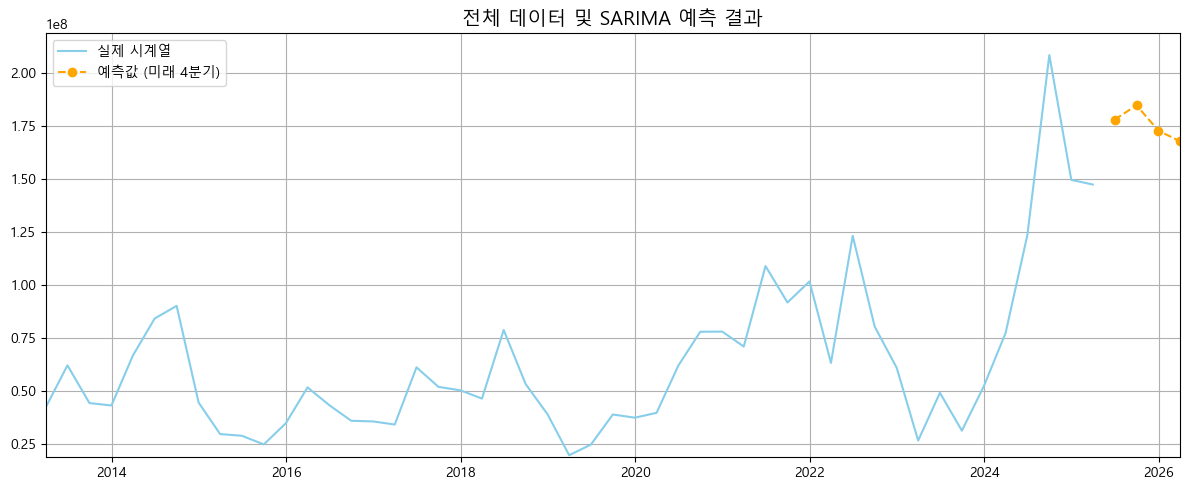


📈 미래 4분기 예측 결과:
2025-06-30    1.780362e+08
2025-09-30    1.847791e+08
2025-12-31    1.727926e+08
2026-03-31    1.678000e+08
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
      lb_stat  lb_pvalue
4    3.567895   0.467630
8    6.830030   0.555077
12  13.264170   0.350136


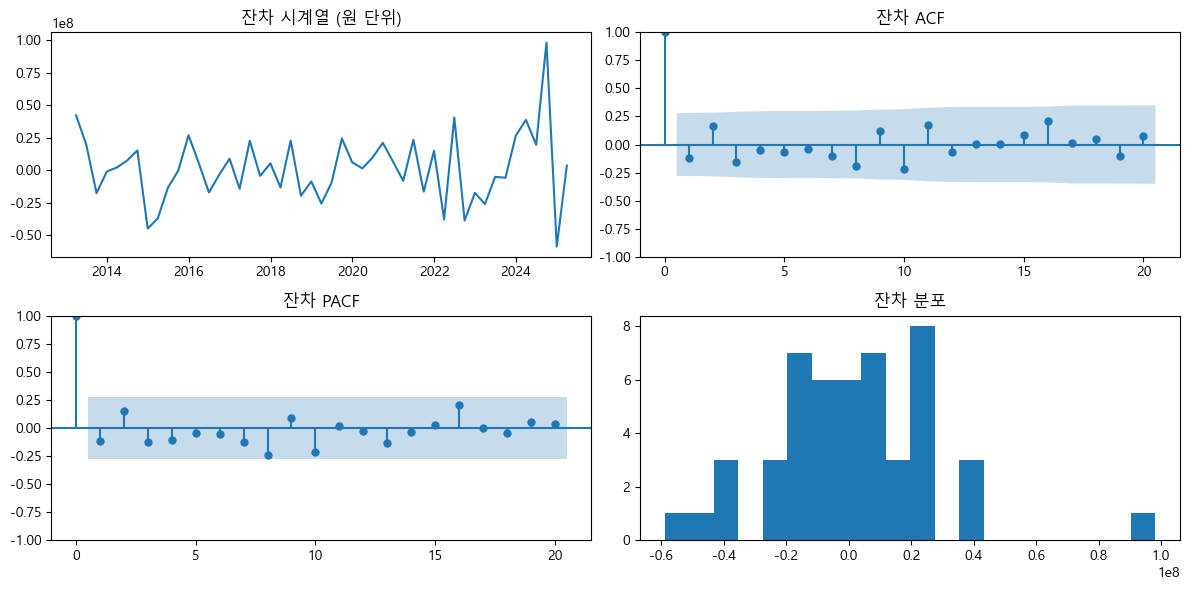

📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(0, 1, 1, 4), AIC=1635.14


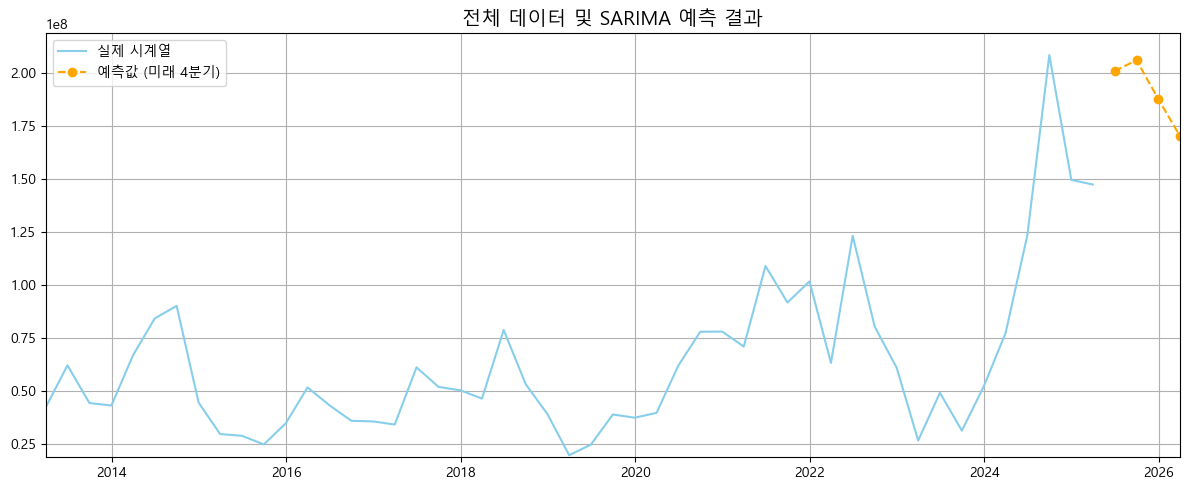


📈 미래 4분기 예측 결과:
2025-06-30    2.009554e+08
2025-09-30    2.060804e+08
2025-12-31    1.875933e+08
2026-03-31    1.702566e+08
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
      lb_stat  lb_pvalue
4    4.683967   0.321287
8    6.388274   0.603825
12  15.912132   0.195294


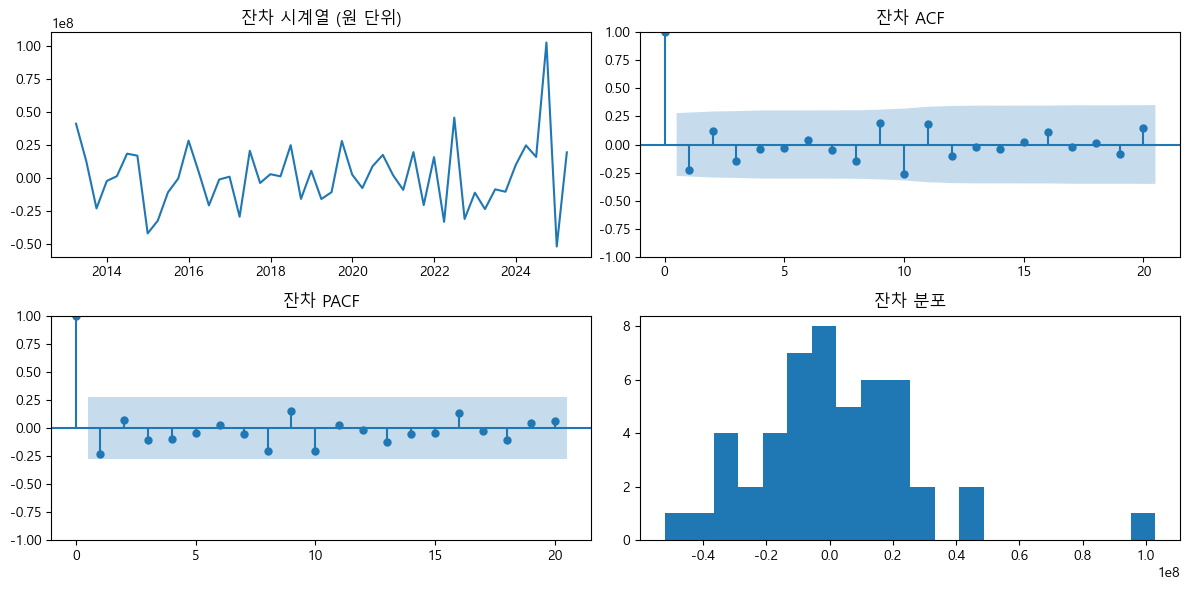

In [9]:
fs_df = fetch_table_data(db_info, "korea_fs_data")
fs_df.rename(columns={'Date': 'date'}, inplace=True)

# 1. indicator 필터링
target_indicator = '매출액(천원)'
filtered_df = fs_df[fs_df['indicator'] == target_indicator].copy()

# 2. 날짜 정제 및 정렬
filtered_df['date'] = pd.to_datetime(filtered_df['date'])
filtered_df.sort_values(by='date', inplace=True)

# 3. value 컬럼이 있는지 확인 및 타입 강제
if 'value' not in filtered_df.columns:
    raise KeyError("'value' 컬럼이 없습니다.")

filtered_df['value'] = pd.to_numeric(filtered_df['value'], errors='coerce')

# 4. 피벗 테이블 생성 (행: date, 열: Symbol, 값: value)
pivot_df = filtered_df.pivot_table(
    index='date',
    columns='symbol',
    values='value',
    aggfunc='first'  # 중복 방지
)

# 5. 전년 동분기 대비 변화율 계산 (4분기 전 대비)
fs_yoy_growth_df = pivot_df.pct_change(periods=4) * 100

endog_df = pivot_df[[tic_name]].reset_index()

temp_df = load_forecast_by_hscode(db_info, hs_code, table_name='korea_monthly_trade_data_forecast')

# 중복 제거
target_export_df = temp_df.drop_duplicates(subset=['date'])

# date를 datetime으로 변환
target_export_df['date'] = pd.to_datetime(target_export_df['date'])

# 분기 추출 및 그룹화
target_export_df['quarter'] = target_export_df['date'].dt.to_period('Q')
quarterly_sum_df = target_export_df.groupby('quarter')['expDlr_forecast_12m'].sum().reset_index()

# datetime 변환 후 추가 계산
quarterly_sum_df['quarter'] = quarterly_sum_df['quarter'].dt.to_timestamp()
quarterly_sum_df['export_qoq_change'] = quarterly_sum_df['expDlr_forecast_12m'].pct_change(periods=1)
quarterly_sum_df['export_yoy_change'] = quarterly_sum_df['expDlr_forecast_12m'].pct_change(periods=4)
quarterly_sum_df['date_month'] = quarterly_sum_df['quarter'] + pd.offsets.QuarterEnd(0)

## 수출 데이터를 불러온다

quarterly_sum_df = get_quarterly_export_forecast(db_info, hs_code)
quarterly_sum_df['date'] = pd.to_datetime(quarterly_sum_df['date_month'])

# 3. date를 인덱스로 설정
quarterly_sum_df.set_index('date', inplace=True)

# ✅ (선택적으로 quarter 컬럼 제거)
quarterly_sum_df.drop(columns='quarter', inplace=True)

quarterly_sum_df = quarterly_sum_df.reset_index()

merged = merge_endog_exog_data(
    endog_df= endog_df,
    exog_df= quarterly_sum_df,
    endog_col=tic_name,
    exog_col='export_yoy_change',
    start_date = st_date,
    end_date = end_date,
)

future_exog_values = quarterly_sum_df[(quarterly_sum_df['date'] >= forecast_start_date) & (quarterly_sum_df['date'] <= forecast_end_date)]['export_yoy_change'].tolist()

forecast_without_exog = forecast_future_4q_with_sarima(merged, date_col='date', value_col='endog_var', exog_col=None,  use_log=False, fixed_variable=0)
forecast_with_exog = forecast_future_4q_with_sarima(merged, date_col='date', value_col='endog_var', exog_col='exog_var', use_log=False, fixed_variable=0)

#### 장기 valuation 지표 예측

🔍 Grid Search 진행 중...
✅ 최적 모형: order=(1, 1, 0), seasonal_order=(1, 1, 1, 4), AIC=288.33


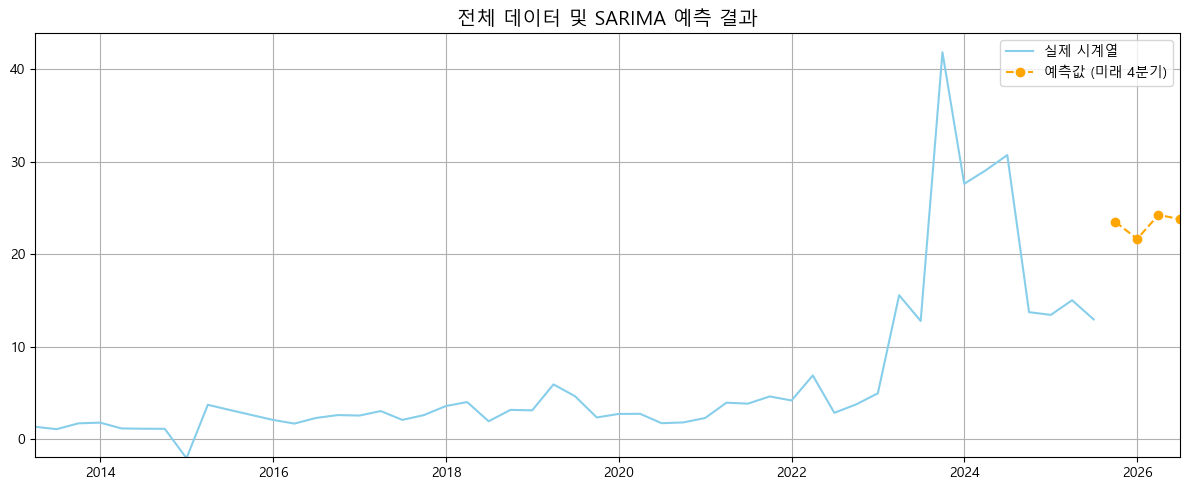


📈 미래 4분기 예측 결과:
2025-09-30    23.495058
2025-12-31    21.651368
2026-03-31    24.250380
2026-06-30    23.797022
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   2.746927   0.601028
8   7.086115   0.527371
12  7.394461   0.830484


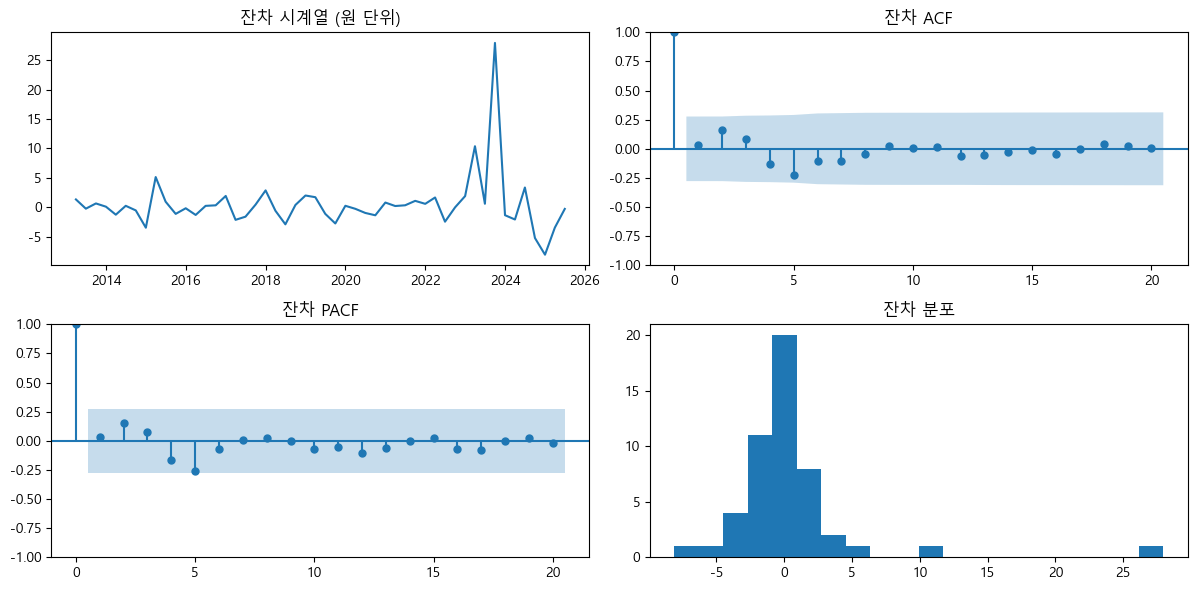

📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(1, 1, 0), seasonal_order=(1, 1, 1, 4), AIC=290.10


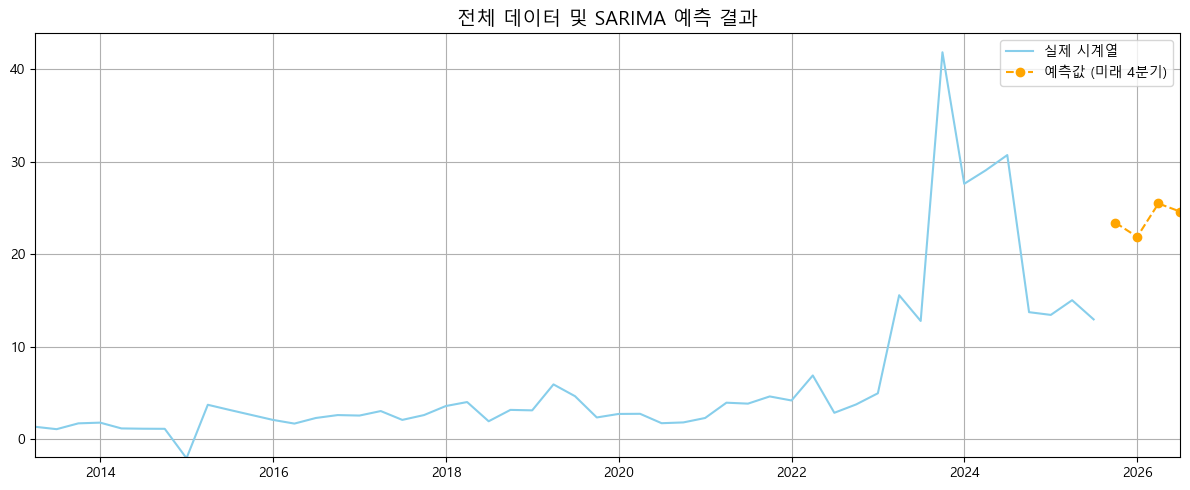


📈 미래 4분기 예측 결과:
2025-09-30    23.407625
2025-12-31    21.877318
2026-03-31    25.488769
2026-06-30    24.616672
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   2.971045   0.562683
8   7.256309   0.509248
12  7.679722   0.809632


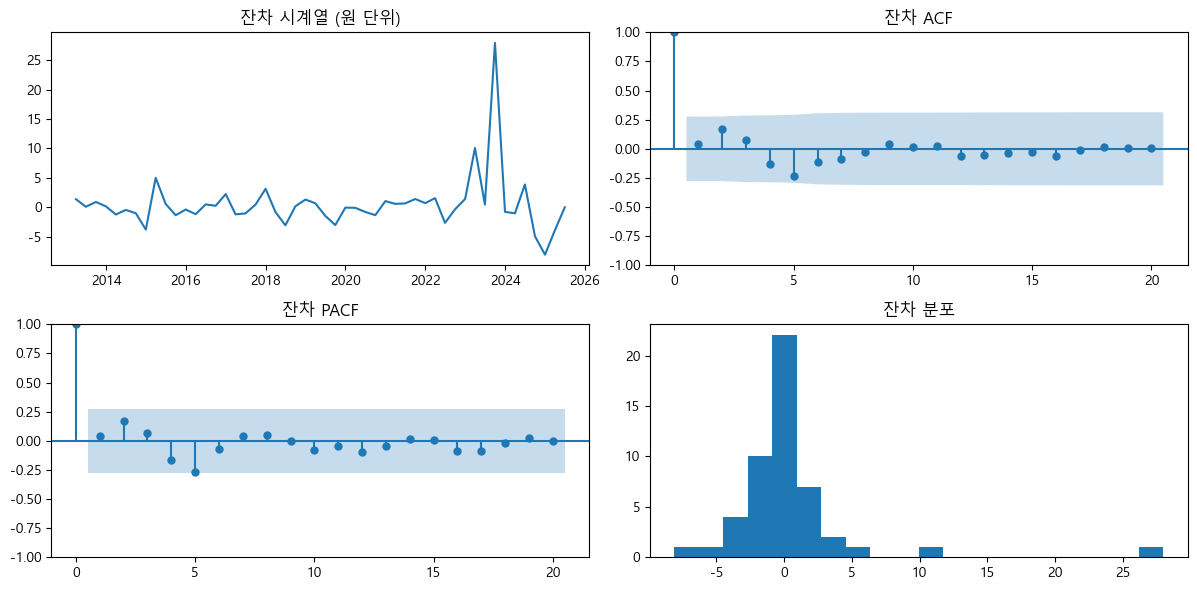

In [12]:
target_indicator = '수정PSR(연율화)(배)'
value_filtered_df = fs_df[(fs_df['indicator'] == target_indicator) & (fs_df['symbol'] == tic_name)].copy()

# 4. 피벗 테이블 생성 (행: date, 열: Symbol, 값: value)
pivot_df = value_filtered_df.pivot_table(
    index='date',
    columns='symbol',
    values='value',
    aggfunc='first'  # 중복 방지
)

value_endog_df = pivot_df[[tic_name]].reset_index()

# 'date' 컬럼이 datetime 타입이 아니라면 변환
value_endog_df['date'] = pd.to_datetime(value_endog_df['date'])
# date 컬럼을 인덱스로 설정 (분기별 재샘플링을 위해)
value_endog_df = value_endog_df.set_index('date')
quarterly_avg_df = value_endog_df.resample('Q').mean()
quarterly_avg_reset = quarterly_avg_df.reset_index()

merged_value_exog = merge_endog_exog_data(
    endog_df = quarterly_avg_reset,
    exog_df = quarterly_sum_df,
    endog_col = tic_name,
    exog_col = 'export_yoy_change',
    start_date = st_date,
    end_date = forecast_end_date
)

ratio_forecast_result_without_exog = forecast_future_4q_with_sarima(merged_value_exog , date_col='date', value_col='endog_var', exog_col=None,  use_log=False, fixed_variable=0)
ratio_forecast_result_with_exog = forecast_future_4q_with_sarima(merged_value_exog , date_col='date', value_col='endog_var', exog_col = 'exog_var',  use_log=False, fixed_variable=0)



In [18]:
# ✅ 해당 ticker 만 추출
df_tic = filtered_df[filtered_df['symbol'] == tic_name].copy()

# ✅ indicator 가 "매출액(천원)" 인 것만 추출
df_sales = df_tic[df_tic['indicator'] == "매출액(천원)"]

# ✅ pivot (date 를 index, indicator 를 칼럼, value 를 값)
revenue_df = df_sales.pivot(
    index='date',
    columns='indicator',
    values='value'
).reset_index()

# ✅ multi-index column name 제거
revenue_df.columns.name = None

In [31]:
# ✅ date 컬럼을 datetime 으로 변환
revenue_df['date'] = pd.to_datetime(revenue_df['date'])

# ✅ 날짜 순으로 정렬
revenue_df = revenue_df.sort_values('date').reset_index(drop=True)

# ✅ rolling 으로 4개 분기 합산
revenue_df['revenue_ttm'] = revenue_df['매출액(천원)'].rolling(window=4).sum()

In [29]:
# marketcap_df = fetch_table_data(db_info, "ks_listed_company_daily_marketcap")


# ✅ SQLAlchemy 엔진 생성
engine = create_engine(
    f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}?charset=utf8mb4"
)

# ✅ 조회할 ticker 와 indicator
target_indicator = "시가총액"

# ✅ SQL 쿼리 작성
query = f"""
SELECT date, value
FROM ks_listed_company_daily_marketcap
WHERE ticker = '{tic_name}'
  AND indicator = '{target_indicator}'
ORDER BY date;
"""

# ✅ pandas DataFrame 으로 로드
df_result = pd.read_sql(query, engine)

# ✅ 확인
print(df_result.head())

         date         value
0  2020-01-01  463513509000
1  2020-01-02  455502164400
2  2020-01-03  456074403300
3  2020-01-06  448635297600
4  2020-01-07  449207536500


In [51]:
df_result['date'] = pd.to_datetime(df_result['date'])
revenue_df['date'] = pd.to_datetime(revenue_df['date'])

merged_df = pd.merge(df_result, revenue_df[['date', 'revenue_ttm']], on='date', how='left').ffill()

In [55]:
merged_df['PSR'] = merged_df['value']/(merged_df['revenue_ttm']*1000)

In [56]:
merged_df

,date,value,revenue_ttm,PSR
0,2020-01-01,463513509000,NaN,NaN
1,2020-01-02,455502164400,NaN,NaN
2,2020-01-03,456074403300,NaN,NaN
3,2020-01-06,448635297600,NaN,NaN
4,2020-01-07,449207536500,NaN,NaN
...,...,...,...,...
1429,2025-06-24,8844972160000,6.289913e+08,14.062154
1430,2025-06-25,9292939500000,6.289913e+08,14.774353
1431,2025-06-26,9883875140000,6.289913e+08,15.713851
1432,2025-06-27,9807625380000,6.289913e+08,15.592625


In [28]:
marketcap_df['ticker'].unique().tolist()

['AA005930',
 'AA000660',
 'AA005935',
 'AA035420',
 'AA207940',
 'AA005380',
 'AA012330',
 'AA068270',
 'AA051910',
 'AA005490',
 'AA028260',
 'AA055550',
 'AA105560',
 'AA051900',
 'AA017670',
 'AA034730',
 'AA000270',
 'AA015760',
 'AA006400',
 'AA018260',
 'AA032830',
 'AA096770',
 'AA035720',
 'AA033780',
 'AA003550',
 'AA036570',
 'AA066570',
 'AA090430',
 'AA000810',
 'AA086790',
 'AA010950',
 'AA009150',
 'AA009540',
 'AA316140',
 'AA010130',
 'AA251270',
 'AA011170',
 'AA091990',
 'AA030200',
 'AA021240',
 'AA002790',
 'AA024110',
 'AA035250',
 'AA032640',
 'AA018880',
 'AA034220',
 'AA267250',
 'AA086280',
 'AA006800',
 'AA028300',
 'AA078930',
 'AA000720',
 'AA010140',
 'AA029780',
 'AA004020',
 'AA271560',
 'AA161390',
 'AA004990',
 'AA088980',
 'AA071050',
 'AA023530',
 'AA097950',
 'AA028050',
 'AA005830',
 'AA005940',
 'AA008770',
 'AA012750',
 'AA139480',
 'AA000120',
 'AA035760',
 'AA036460',
 'AA016360',
 'AA241560',
 'AA128940',
 'AA047810',
 'AA011070',
 'AA081660',